# Gender+Lexrank on rule based

In [ ]:
# Install spacy if not already installed
!pip install spacy pandas openpyxl

# Import libraries
import spacy
import pandas as pd

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import pandas as pd

# Load full dataset
file_path = "/content/sample_data/output.xlsx"
df = pd.read_excel(file_path)

# Keep only clean_text column (still as DataFrame)
df = df[["cf_bert"]].dropna()

# Check
df.head()

,cf_bert
0,take that .... this me too is a well orchestra...
1,only 40 charges and thousands of cries for hel...
2,former cricketer and cricket association of be...
3,my dream is that one day everyone will know wh...
4,"still,better than my neighbour or'stalker' as ..."


In [ ]:
# Define gender-specific keywords
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}

# Function to classify gender based on Spacy NER
def classify_gender_ner(text):
    doc = nlp(str(text))  # Process text with Spacy

    male_count = sum(1 for token in doc if token.text.lower() in male_terms)
    female_count = sum(1 for token in doc if token.text.lower() in female_terms)

    if male_count > female_count:
        return "Male"
    elif female_count > male_count:
        return "Female"
    elif male_count == female_count and male_count > 0:
        return "Both"
    else:
        return "Neutral/Unclear"


In [ ]:
df["Gender_Category"] = df["cf_bert"].astype(str).apply(classify_gender_ner)
df.head(50)

,cf_bert,Gender_Category
0,take that .... this me too is a well orchestra...,Female
1,only 40 charges and thousands of cries for hel...,Neutral/Unclear
2,former cricketer and cricket association of be...,Neutral/Unclear
3,my dream is that one day everyone will know wh...,Neutral/Unclear
4,"still,better than my neighbour or'stalker' as ...",Female
5,louis ck now stands also as short-form.,Neutral/Unclear
6,if you excuse your boys behavior you create an...,Male
7,since my moment: * someone tried to unsuccessf...,Neutral/Unclear
8,"sharman joshi opens up on : \""maligning someon...",Neutral/Unclear
9,"is a movement toward victimization, g.o.p. sen...",Neutral/Unclear


In [ ]:
print(df.columns)

Index(['cf_bert', 'Gender_Category'], dtype='object')


In [ ]:
# Create separate DataFrames
male_tweets = df[df["Gender_Category"] == "Male"]
female_tweets = df[df["Gender_Category"] == "Female"]
both_tweets = df[df["Gender_Category"] == "Neutral/Unclear"]

In [ ]:
print("Male:", len(male_tweets))
print("Female:", len(female_tweets))
print("Both:", len(both_tweets))

Male: 138
Female: 103
Both: 187


In [ ]:
male_tweets = male_tweets[["cf_bert"]]
female_tweets = female_tweets[["cf_bert"]]
both_tweets = both_tweets[["cf_bert"]]

In [ ]:
male_tweets.to_excel("/content/sample_data/male_tweets.xlsx", index=False)
female_tweets.to_excel("/content/sample_data/female_tweets.xlsx", index=False)
both_tweets.to_excel("/content/sample_data/both_tweets.xlsx", index=False)

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def compute_similarity_bert(texts):
    # Encode sentences → embeddings
    embeddings = model.encode(texts, convert_to_numpy=True)

    # Cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)

    return similarity_matrix

In [ ]:
male_texts = male_tweets["cf_bert"].astype(str).tolist()
female_texts = female_tweets["cf_bert"].astype(str).tolist()
both_texts = both_tweets["cf_bert"].astype(str).tolist()

In [ ]:
male_sim = compute_similarity_bert(male_texts)
female_sim = compute_similarity_bert(female_texts)
both_sim = compute_similarity_bert(both_texts)

In [ ]:
def create_pairs(texts, sim_matrix):
    pairs = []

    n = len(texts)

    for i in range(n):
        for j in range(i + 1, n):   # avoid duplicates + self-pairs
            pairs.append({
                "Tweet 1": texts[i],
                "Tweet 2": texts[j],
                "Similarity Score": sim_matrix[i][j]
            })

    return pd.DataFrame(pairs)

In [ ]:
male_similarity_df = create_pairs(male_texts, male_sim)
female_similarity_df = create_pairs(female_texts, female_sim)
both_similarity_df = create_pairs(both_texts, both_sim)

In [ ]:
male_similarity_df.head()

,Tweet 1,Tweet 2,Similarity Score
0,if you excuse your boys behavior you create an...,thanks for being the rare voice in the industr...,0.093923
1,if you excuse your boys behavior you create an...,"\""the man who does not require validation from...",0.005316
2,if you excuse your boys behavior you create an...,watching on itv. the kind of oppression of men...,0.121729
3,if you excuse your boys behavior you create an...,first hand account of a survivor from . public...,0.110135
4,if you excuse your boys behavior you create an...,"no hindu vrat is compulsory , generally men wh...",0.004750


In [ ]:
male_similarity_df.to_excel("/content/sample_data/male_similarity.xlsx", index=False)
female_similarity_df.to_excel("/content/sample_data/female_similarity.xlsx", index=False)
both_similarity_df.to_excel("/content/sample_data/both_similarity.xlsx", index=False)

In [ ]:
assert len(male_similarity_df) >= 50

male_50_pairs = male_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

male_50_pairs.to_excel("/content/sample_data/male_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(female_similarity_df) >= 50

female_50_pairs = female_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

female_50_pairs.to_excel("/content/sample_data/female_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(both_similarity_df) >= 50

both_50_pairs = both_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

both_50_pairs.to_excel("/content/sample_data/both_50_random_pairs.xlsx", index=False)

In [ ]:
male_tweets_list = list(
    set(male_50_pairs["Tweet 1"]).union(set(male_50_pairs["Tweet 2"]))
)

In [ ]:
!pip install lexrank
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([male_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
male_summary = lx.get_summary(
    male_tweets_list,
    summary_size=25,
    threshold=0.15   # you can change (e.g., 0.2 / 0.3)
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 613.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 3.6 MB/s eta 0:00:00


In [ ]:
summary_df = pd.DataFrame({"summary": male_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/male_summary.xlsx", index=False)
print("Summary saved as male_summary.xlsx")

Summary saved as male_summary.xlsx


In [ ]:
print("Male Summary:\n")
for i, s in enumerate(male_summary, 1):
    print(f"{i}. {s}")

Male Summary:

1. as i cry and succumb to mental exhaustion because of , i remember the friendships men forged and solidarity we showered upon each other. each one of you who has helped, supported, fought the war, been there relentlessly - i will never forget. thank you. i love you.
2. if someone was sleeping till 10 or more years and all of sudden he comeout saying its a complete faliure of system if they are being entertained. it will increase more .
3. hello, ms. burke! do you find it acceptable that and have colluded with the indian government to silence the voices of kashmiri men as they seek justice for decades of militarised sexual violence by the indian occupation forces?
4. is . is just hungry for cash bc he takes advantage of the movement. but him career is over. no one will want to hire him now.
5. i respect tanushree dutta he is genuine and good actor but at the same time i don't understand how he can say about rakhi savant he is also a lady first... acc to me he is also a 

In [ ]:
female_tweets_list = list(
    set(female_50_pairs["Tweet 1"]).union(set(female_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([female_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
female_summary = lx.get_summary(
    female_tweets_list,
    summary_size=25,
    threshold=0.34  # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": female_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/female_summary.xlsx", index=False)
print("Summary saved as female_summary.xlsx")

Summary saved as female_summary.xlsx


In [ ]:
print("Female Summary:\n")
for i, s in enumerate(female_summary, 1):
    print(f"{i}. {s}")

Female Summary:

1. when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with hers story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!
2. my model friend has taken the initiative to come forward and speak about hers experience in the fashion industry. lead the way kawal. proud of you. hope more women come forward to expose their experience with the predators around.
3. still,better than my neighbour or'stalker' as we like to call him,who i v gently turned down so naturally went on an intimidation spree, inc what felt like constantly standing outside my front door listening,which went on for 18ms. i was lucky, hers ex said she was violent
4. just finished 's excellent book \"dream city\" in which marion barry is accused of multiple physical and sexual assaults by women, including one testifying under oath that barry raped her. so callous to encourage selfies w/ gross 

In [ ]:
both_tweets_list = list(
    set(both_50_pairs["Tweet 1"]).union(set(both_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([both_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
both_summary = lx.get_summary(
    both_tweets_list,
    summary_size=25,
    threshold=0.25   # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": both_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/both_summary.xlsx", index=False)
print("Summary saved as both_summary.xlsx")

Summary saved as both_summary.xlsx


In [ ]:
print("Both Summary:\n")
for i, s in enumerate(both_summary, 1):
    print(f"{i}. {s}")

Both Summary:

1. why matters more than ever in the age of . by
2. important new on migrant caregivers in canada from to raise awareness on workplace abuse and exploitation. download here:
3. thank you for a fantastic session which was and on the of under
4. in the current climate of if someone did that to you at your place of work would you just let it go? or should it be considered sexual assault?
5. a3 experience can prevent reoccurrence to others . if nobody had, maybe wouldn't exist.
6. but the analysis shows that the movement shook, and is still shaking, power structures in societys most visible sectors.\"
7. has become a platform to level allegations on other people to thinking comes on public platform listen harassed by coz of this r soft target
8. ... movement now has changed into false complaints allegations.. jo log publicity nahi le paa re the, suddenly isko platform samaj ke aagye hai.. aise kuch examples
9. pmo used derogatory language against victims, rejected request to

In [ ]:
!pip install bertopic sentence-transformers networkx openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
male_df = pd.read_excel("/content/sample_data/male_summary.xlsx")
female_df = pd.read_excel("/content/sample_data/female_summary.xlsx")
both_df = pd.read_excel("/content/sample_data/both_summary.xlsx")

male_summary = male_df["summary"].dropna().astype(str).tolist()
female_summary = female_df["summary"].dropna().astype(str).tolist()
both_summary = both_df["summary"].dropna().astype(str).tolist()

# -----------------------------
# Combine all summaries
# -----------------------------
combined_sentences = male_summary + female_summary + both_summary

print(f"Total combined sentences: {len(combined_sentences)}")

Total combined sentences: 75


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(combined_sentences, convert_to_tensor=True)
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
threshold = 0.05
G = nx.Graph()

# Add nodes
for idx, sentence in enumerate(combined_sentences):
    G.add_node(idx, sentence=sentence)

# Add edges based on similarity threshold
for i in range(len(combined_sentences)):
    for j in range(i+1, len(combined_sentences)):
        sim = similarity_matrix[i][j]
        if sim >= threshold:
            G.add_edge(i, j, weight=sim)

In [ ]:
scores = nx.pagerank(G, weight='weight')
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(combined_sentences)), reverse=True)
summary_lexrank = [sent for score, sent in ranked_sentences[:25]]

# Print summary
print("\n".join(summary_lexrank))

when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with hers story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!
more than how abuse gaslighting has been intruded in this 'relationship'.. i clap to this man for pointng out how some so called elite feminist men wl scream out for in no blnk of an eye, conveniently support the abusers if they knew them!
hello, ms. burke! do you find it acceptable that and have colluded with the indian government to silence the voices of kashmiri men as they seek justice for decades of militarised sexual violence by the indian occupation forces?
and to think that i used to find hers advice column in the telegraph sunday magazine immensely entertaining. and hers outrage over issues like ram rahim etc. woman up and face the music. apologise or do what u have to instead of hiding like this.
has become a platform to level allegations on ot

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')   # <-- IMPORTANT (your error specifically asks this)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def count_gender_terms(summary, male_terms, female_terms):
    male_count = 0
    female_count = 0
    stop_words = set(stopwords.words('english'))  # This line requires the stopwords import

    for sentence in summary:
        words = word_tokenize(sentence.lower())  # Tokenize each sentence into words
        filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

        for word in filtered_words:
            if word in male_terms:
                male_count += 1
            elif word in female_terms:
                female_count += 1

    return male_count, female_count

In [ ]:
# Gender term lists
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}

In [ ]:
combined_summary = [
    "when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with hers story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!",
    "more than how abuse gaslighting has been intruded in this 'relationship'.. i clap to this man for pointng out how some so called elite feminist men wl scream out for in no blnk of an eye, conveniently support the abusers if they knew them!",
    "hello, ms. burke! do you find it acceptable that and have colluded with the indian government to silence the voices of kashmiri men as they seek justice for decades of militarised sexual violence by the indian occupation forces?",
    "and to think that i used to find hers advice column in the telegraph sunday magazine immensely entertaining. and hers outrage over issues like ram rahim etc. woman up and face the music. apologise or do what u have to instead of hiding like this.",
    "has become a platform to level allegations on other people to thinking comes on public platform listen harassed by coz of this r soft target",
    "abusers aren't victims, opportunists aren't crusaders. slut shamers shudn't talk about slut shaming cowards shudn't pretend to be warriors. this is what sonam mahajan who i once considered a friend did to me. telling this now seeing him blatant bigotry hypocrisy around",
    "must be horrible to be female in their world. where's the brigade? no doubt keeping quiet for the good of diversity.",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting him editor-predator . he needs our support.",
    "and it would be because of the actions of a few girls like who abuse , one day it will probably have its own movement as a mark of protest.",
    "no for bengalurus garment workers - \"while perceptions about sexual violence in workplaces is changing and more men are opening up about their experiences, the garment workers sector, mostly comprising men employees, continues to suffer.\"",
    "in the past few days, several incidents of faux feminism have woken people up against the \"believe all women\" bullshit being propagated in light of the movement.",
    "... movement now has changed into false complaints allegations.. jo log publicity nahi le paa re the, suddenly isko platform samaj ke aagye hai.. aise kuch examples",
    "i once predicted abt rise of feminism, and we can now see the same in form of .. this is nothing but but many male friends has to sacrifice their life, career for men publicity..",
    "in the age of and biased laws, women are suffering. let's paint airtel delhi half marathon on 21st oct with sufferings and pain of women to bring the focus back...",
    "that to they lied and now they want to lynch every woman on earth . the whole is stupid . its dangerous to believe every man . no woman is safe anymore when someone doesnt like you they cry . it can happen to everyone",
    "has announced she will sue the lady for allegations. this should be done by every woman who has been accused and if they are genuinely affected by false allegations. just because u have a hashtag u can't do character assassination",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "in india, men are no longer prepared to stay silent. i write this for priya, vinta, ghazala and all the incredible men who enabled us to break our silence.",
    "'i was shamed and humiliated': adhyayan suman on sharing hers story 2 years ago against kangana ranaut | bollywood news if woman suffer media house never support , its not 4 both , dont get fool . to stop .",
    "of all the rags to put it out, it has to be radar! online. however it's a legit court doc! truth is out! yeah they're trying to bury it and spread more bs about potc and john mcafree. wake up, y'all need to stop dismissing male abuse survivors.",
    "too bad you don't really believe in the power of truth. how can you live with yourself, knowingly voting for an alcoholic abuser of women. next time i am sexually assaulted i will first ask if anyone would like to witness for prosperity's sake screw you.",
    "the feminist movt finds itself in the midst of a generational struggle and is consolidating into an identity movt - my article in today's indian express edition.",
    "mechanisms need to exist for freelance journalists to be able to report sexual abuse and misconduct. men should feel safe to report it. its doable and can be done, but i dont see that happening. -",
    "make no mistake. this is not only an attempt to discredit mueller, but also to discredit the entire movement. expect to hear much complaining that democrats won't believe this accuser after saying believe women.",
    "save innocent women mmt coz in schools, colleges, universities, offices, show biz girls r seen as low hanging fruits. i thinks"
]
male_count, female_count = count_gender_terms(combined_summary, male_terms, female_terms)

# Avoid division by zero
total = male_count + female_count
if total > 0:
    male_ratio = male_count / total
    female_ratio = female_count / total
    bias_score = female_ratio - male_ratio
else:
    male_ratio = female_ratio = bias_score = 0

# Display results
print(f"Male Mentions: {male_count}")
print(f"Female Mentions: {female_count}")
print(f"Bias Score (female - male): {bias_score:.2f}")

if bias_score > 0:
    print("🟣 Summary is biased toward females.")
elif bias_score < 0:
    print("🔵 Summary is biased toward males.")
else:
    print("⚪ Summary appears neutral.")

Male Mentions: 13
Female Mentions: 20
Bias Score (female - male): 0.21
🟣 Summary is biased toward females.


 Male Mentions: 16
 Female Mentions: 25
 Bias Score (female - male): 0.2195
 Summary is biased toward females.


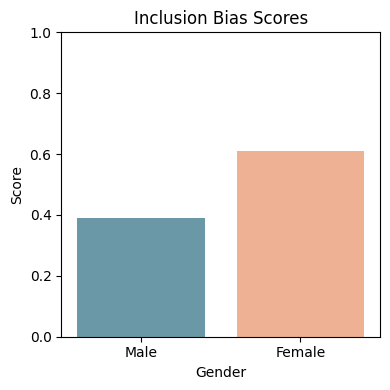

(0.3902439024390244, 0.6097560975609756, 0.2195121951219512)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}


# -----------------------------
# CORRECT FUNCTION
# -----------------------------
def calculate_weighted_bias(summary, male_terms, female_terms):

    # Join if list
    if isinstance(summary, list):
        summary = ' '.join(summary)

    # Lowercase
    summary = summary.lower()

    # 🔥 KEY FIX: clean tokenization
    words = re.findall(r'\b[a-z]+\b', summary)

    # Frequency count
    word_freq = Counter(words)

    # Count using SAME logic as first method
    male_count = sum(word_freq[word] for word in word_freq if word in male_terms)
    female_count = sum(word_freq[word] for word in word_freq if word in female_terms)

    total = male_count + female_count

    if total > 0:
        male_ratio = male_count / total
        female_ratio = female_count / total
        bias_score = female_ratio - male_ratio
    else:
        male_ratio = female_ratio = bias_score = 0

    # -----------------------------
    # Print results
    # -----------------------------
    print(f" Male Mentions: {male_count}")
    print(f" Female Mentions: {female_count}")
    print(f" Bias Score (female - male): {bias_score:.4f}")

    if bias_score > 0:
        print(" Summary is biased toward females.")
    elif bias_score < 0:
        print(" Summary is biased toward males.")
    else:
        print(" Summary appears neutral.")

    # -----------------------------
    # Optional visualization
    # -----------------------------
    df = pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Score': [male_ratio, female_ratio]
    })

    plt.figure(figsize=(4,4))
    sns.barplot(x='Gender', y='Score', data=df,
                palette=["#609db0", "#fdac84"])
    plt.title("Inclusion Bias Scores")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

    return male_ratio, female_ratio, bias_score

combined_summary = [
    "when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with hers story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!",
    "more than how abuse gaslighting has been intruded in this 'relationship'.. i clap to this man for pointng out how some so called elite feminist men wl scream out for in no blnk of an eye, conveniently support the abusers if they knew them!",
    "hello, ms. burke! do you find it acceptable that and have colluded with the indian government to silence the voices of kashmiri men as they seek justice for decades of militarised sexual violence by the indian occupation forces?",
    "and to think that i used to find hers advice column in the telegraph sunday magazine immensely entertaining. and hers outrage over issues like ram rahim etc. woman up and face the music. apologise or do what u have to instead of hiding like this.",
    "has become a platform to level allegations on other people to thinking comes on public platform listen harassed by coz of this r soft target",
    "abusers aren't victims, opportunists aren't crusaders. slut shamers shudn't talk about slut shaming cowards shudn't pretend to be warriors. this is what sonam mahajan who i once considered a friend did to me. telling this now seeing him blatant bigotry hypocrisy around",
    "must be horrible to be female in their world. where's the brigade? no doubt keeping quiet for the good of diversity.",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting him editor-predator . he needs our support.",
    "and it would be because of the actions of a few girls like who abuse , one day it will probably have its own movement as a mark of protest.",
    "no for bengalurus garment workers - \"while perceptions about sexual violence in workplaces is changing and more men are opening up about their experiences, the garment workers sector, mostly comprising men employees, continues to suffer.\"",
    "in the past few days, several incidents of faux feminism have woken people up against the \"believe all women\" bullshit being propagated in light of the movement.",
    "... movement now has changed into false complaints allegations.. jo log publicity nahi le paa re the, suddenly isko platform samaj ke aagye hai.. aise kuch examples",
    "i once predicted abt rise of feminism, and we can now see the same in form of .. this is nothing but but many male friends has to sacrifice their life, career for men publicity..",
    "in the age of and biased laws, women are suffering. let's paint airtel delhi half marathon on 21st oct with sufferings and pain of women to bring the focus back...",
    "that to they lied and now they want to lynch every woman on earth . the whole is stupid . its dangerous to believe every man . no woman is safe anymore when someone doesnt like you they cry . it can happen to everyone",
    "has announced she will sue the lady for allegations. this should be done by every woman who has been accused and if they are genuinely affected by false allegations. just because u have a hashtag u can't do character assassination",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "in india, men are no longer prepared to stay silent. i write this for priya, vinta, ghazala and all the incredible men who enabled us to break our silence.",
    "'i was shamed and humiliated': adhyayan suman on sharing hers story 2 years ago against kangana ranaut | bollywood news if woman suffer media house never support , its not 4 both , dont get fool . to stop .",
    "of all the rags to put it out, it has to be radar! online. however it's a legit court doc! truth is out! yeah they're trying to bury it and spread more bs about potc and john mcafree. wake up, y'all need to stop dismissing male abuse survivors.",
    "too bad you don't really believe in the power of truth. how can you live with yourself, knowingly voting for an alcoholic abuser of women. next time i am sexually assaulted i will first ask if anyone would like to witness for prosperity's sake screw you.",
    "the feminist movt finds itself in the midst of a generational struggle and is consolidating into an identity movt - my article in today's indian express edition.",
    "mechanisms need to exist for freelance journalists to be able to report sexual abuse and misconduct. men should feel safe to report it. its doable and can be done, but i dont see that happening. -",
    "make no mistake. this is not only an attempt to discredit mueller, but also to discredit the entire movement. expect to hear much complaining that democrats won't believe this accuser after saying believe women.",
    "save innocent women mmt coz in schools, colleges, universities, offices, show biz girls r seen as low hanging fruits. i thinks"
]
# -----------------------------
# RUN
# -----------------------------
calculate_weighted_bias(combined_summary, male_terms, female_terms)